## **Predicting Aid Project Duration and Cost Efficiency Using Enhanced Machine Learning and NLP in Kenya**

## **1. Introduction**

### **Background**

Humanitarian and development aid initiatives play a critical role in addressing socioeconomic challenges in Kenya, including healthcare, education, energy access, and governance. These projects are funded and implemented by various international and local organisations and are reported through the International Aid Transparency Initiative (IATI), which promotes transparency and accountability in aid activities. The IATI datasets provide rich information on project timelines, funding levels, sectors, and implementing organisations. However, despite the availability of such detailed data, it remains largely underutilised for predictive analytics and decision support. Leveraging machine learning and natural language processing techniques on this data can provide valuable insights into project behavior, enabling stakeholders to improve planning, resource allocation, and monitoring of development interventions.

### **Research Problem**

Despite the availability of detailed aid activity data, stakeholders such as donors and policymakers still face significant uncertainty in understanding how long projects will take and how efficiently resources are utilized. Poor estimation of project duration can lead to delays, cost overruns, and reduced impact, while inefficient allocation of funds can limit the effectiveness of development interventions. Key challenges include:

* Limited use of historical project data to predict future project duration  
* Lack of data-driven methods to evaluate project cost efficiency  
* Variability in project timelines and reporting practices across organisations  

Without predictive and analytical tools, decision-making remains largely reactive rather than proactive. There is therefore a need to develop enhanced machine learning approaches that can not only predict project duration but also provide insights into how efficiently resources are utilized and what factors influence these outcomes.

### **Objectives**

1. To perform descriptive and diagnostic analytics to explore patterns in aid project timelines, funding, sectors, and reporting organisations.  
2. To develop an enhanced machine learning model that predicts **project duration** using project metadata and textual information.  
3. To design a predictive model for **project cost efficiency**, defined as the relationship between financial expenditure and project duration.  
4. To apply explainable machine learning techniques to identify key factors influencing project duration and efficiency.  

This integrated approach demonstrates how advanced data science techniques, including ensemble learning and natural language processing, can support evidence-based decision-making in humanitarian and development programming.

### Import Libraries

In [74]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Dates
from datetime import datetime

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# For improvement
from sklearn.decomposition import PCA

# Evaluation
from sklearn.model_selection import cross_val_score

# Explainability
import shap

# Clustering
from sklearn.cluster import KMeans

# Pipeline utilities
from scipy.sparse import hstack

# Saving models
import joblib

## **2. Methodology, Results and Discussion**

### **Data Description**

This project uses the **“IATI activities in Kenya (no location information)"** dataset that was obtained from the **Humanitarian Data Exchange (HDX)**.  It includes comprehensive records of development and humanitarian aid operations reported under the **International Aid Transparency Initiative (IATI)** , encompassing projects carried out in Kenya by various organisations, such as donor institutions, NGOs, and UN agencies.  Project timelines, reporting organisations, funding sources, sectoral allocation, and country coverage can all be analysed because each row represents a single activity/sector combination.

 As a result of the raw export from HDX, every variable in the original CSV is of **object type**.  Numerical and date fields are suitably cast after data cleaning and type conversion to facilitate insightful analysis and predictive modelling.

| Variable            | Description                             | Original Type | Cleaned Type | Key Insights                                                          |
| ------------------- | --------------------------------------- | ------------- | ------------ | --------------------------------------------------------------------- |
| **aid**             | Unique project identifier (URL)         | object        | object       | Primary key for tracking projects                                     |
| **reporting**       | Reporting organization name             | object        | object       | Enables organizational-level analysis                                 |
| **reporting_ref**   | Reporting organization reference code   | object        | object       | Used for grouping and consistency checks                              |
| **funder_ref**      | Funder reference code                   | object        | object       | Often same as reporting_ref, indicates funding source                 |
| **title**           | Project title/description               | object        | object       | Text feature for NLP analysis of project goals                        |
| **slug**            | Activity tag or sector code             | object        | object       | Proxy for project sector classification                               |
| **status_code**     | Project status                          | object        | object       | Target variable for classification (“Implementation”, “Closed”, etc.) |
| **day_start**       | Project start date                      | object        | datetime64   | Derived features: month, year for modeling                            |
| **day_end**         | Project end date                        | object        | datetime64   | Used to compute **day_length**                                        |
| **day_length**      | Project duration in days                | object        | float64      | Target variable for regression                                        |
| **commitment_gbp**  | Committed funds in GBP                  | object        | float64      | Measures intended scale of project                                    |
| **spend_gbp**       | Actual spending in GBP                  | object        | float64      | Indicates execution performance                                       |
| **commitment_cad**  | Committed funds in CAD                  | object        | float64      | Multi-currency reporting                                              |
| **spend_cad**       | Actual spending in CAD                  | object        | float64      | Multi-currency spending assessment                                    |
| **flags**           | Reporting flags                         | object        | int64        | Binary indicator of reporting issues                                  |
| **sector_group**    | High-level sector category              | object        | object       | Used for sectoral grouping in analysis                                |
| **sector_code**     | Detailed sector code                    | object        | object       | OECD DAC classification, detailed sector insights                     |
| **sector_percent**  | Share of project in sector (%)          | object        | float64      | Useful for weighted sector analysis                                   |
| **country_code**    | Country of implementation               | object        | object       | All rows correspond to Kenya                                          |
| **country_percent** | Share of project allocated to Kenya (%) | object        | float64      | Typically 100% for single-country projects                            |

**The data's source**

 The dataset was obtained through the **IATI registry** from **HDX**.  The data includes contributions from several reporting organisations and is made publicly available under standard HDX licensing.

 **Period Collected**

 Records from **projects from 01 January 1980 to 01 May 2026** span more than 40 years of development and humanitarian endeavours in Kenya.

 **Collection Method** 
 
 HDX aggregates and exports data as a CSV after it is **self-reported by organisations** via IATI-compliant XML submissions.  Sector-level analysis is made possible by the unique activity-sector combinations represented by each row.

**Conditions for Collection**

 Inconsistencies, missing values, and mixed data types are all characteristics of real-world reporting practices.  In order to make numerical and date fields usable for exploratory and predictive analytics, all columns were first stored as **object type**, necessitating careful **data cleaning and type conversion**.  The dataset supports machine learning models for **project duration prediction** and **status classification** and offers a thorough picture of aid operations in Kenya.


### Load Dataset

In [3]:
df = pd.read_csv("../Data/iati-activities-in-kenya-no-location-information.csv")

# Remove metadata row
df = df.iloc[1:].reset_index(drop=True)

df.head()

,aid,reporting,reporting_ref,funder_ref,title,slug,status_code,day_start,day_end,day_length,...,commitment_gbp,spend_gbp,commitment_cad,spend_cad,flags,sector_group,sector_code,sector_percent,country_code,country_percent
0,http://d-portal.org/q.html?aid=NL-KVK-27378529...,Netherlands Enterprise Agency,NL-KVK-27378529,NL-KVK-27378529,Energising Development (ENDEV4),rvo-01,Implementation,2019-11-01,2022-12-31,1156.0,...,0.0,0.0,0.0,0.0,0,"Energy generation, renewable sources","Energy generation, renewable sources - multipl...",100.0,Kenya,3.9215686
1,http://d-portal.org/q.html?aid=US-EIN-30010826...,GlobalGiving,US-EIN-300108263,US-EIN-300108263,Care for babies & empower young mothers in Nai...,globalgiving-activity,Finalisation,2012-04-01,2022-09-20,3824.0,...,0.0,3323.6504,0.0,5666.052,0,NaN,NaN,NaN,Kenya,100.0
2,http://d-portal.org/q.html?aid=NL-KVK-27108436...,Oxfam Novib,NL-KVK-27108436,NL-KVK-27108436,Voice Programme costs Hivos Kenya,onl-activity,Implementation,2016-04-07,2021-12-31,2094.0,...,0.0,838450.94,0.0,1436350.2,0,Government & Civil Society-general,Democratic participation and civil society,100.0,Kenya,100.0
3,http://d-portal.org/q.html?aid=US-EIN-30010826...,GlobalGiving,US-EIN-300108263,US-EIN-300108263,Equip a rural Kenyan library with a computer lab,globalgiving-activity,Finalisation,2012-04-01,2020-08-07,3050.0,...,0.0,9806.812,0.0,16707.918,0,NaN,NaN,NaN,Kenya,100.0
4,http://d-portal.org/q.html?aid=NL-KVK-27378529...,Netherlands Enterprise Agency,NL-KVK-27378529,NL-KVK-27378529,Pilot 2g@there OS (TGOS),rvo-01,Implementation,2011-01-01,2020-07-14,3482.0,...,0.0,0.0,0.0,0.0,0,Business & Other Services,Business policy and administration,44.45,Kenya,22.22


In [4]:
df.dtypes

aid                object
reporting          object
reporting_ref      object
funder_ref         object
title              object
slug               object
status_code        object
day_start          object
day_end            object
day_length         object
description        object
commitment         object
spend              object
commitment_eur     object
spend_eur          object
commitment_gbp     object
spend_gbp          object
commitment_cad     object
spend_cad          object
flags              object
sector_group       object
sector_code        object
sector_percent     object
country_code       object
country_percent    object
dtype: object

In [5]:
df.shape

(27078, 25)

### Data cleaning and preprocessing

#### 1. Convert types

Here, we convert the `day_start` and `day_end` columns to datetime format using `pd.to_datetime()`, coercing errors to NaT to handle any invalid date entries. This ensures that the date columns are in the correct format for further analysis. The `day_length` column should be numeric, so we convert it using `pd.to_numeric()`, coercing errors to NaN to handle any non-numeric entries.

In [6]:
df['day_start'] = pd.to_datetime(df['day_start'], errors='coerce')
df['day_end'] = pd.to_datetime(df['day_end'], errors='coerce')
df['day_length'] = pd.to_numeric(df['day_length'], errors='coerce')
df.dtypes

aid                        object
reporting                  object
reporting_ref              object
funder_ref                 object
title                      object
slug                       object
status_code                object
day_start          datetime64[ns]
day_end            datetime64[ns]
day_length                float64
description                object
commitment                 object
spend                      object
commitment_eur             object
spend_eur                  object
commitment_gbp             object
spend_gbp                  object
commitment_cad             object
spend_cad                  object
flags                      object
sector_group               object
sector_code                object
sector_percent             object
country_code               object
country_percent            object
dtype: object

#### 2. Verify Day length accuracy

Here we confirm whether the `day_length` column matches the difference between `day_end` and `day_start` columns. We end up finding out that there are discrepancies, which we will need to address. **14 rows** do not match and it is clear that the this is due to the `day_length` column having missing values for those rows. We therefore compute the `day_length` column based on the date difference instead. After this **12 rows** are fixed and **2 rows** remain with False for the match check. We review these rows separately and realize that the reason the compution did not work is because these rows have missing values in the `day_start` column. This will need to be addressed later.

In [7]:
# Confirm that day_length column is actually equal to day_end - day_start
df['day_length'] == (df['day_end'] - df['day_start']).dt.days

0        True
1        True
2        True
3        True
4        True
         ... 
27073    True
27074    True
27075    True
27076    True
27077    True
Length: 27078, dtype: bool

In [8]:
matches = df['day_length'] == (df['day_end'] - df['day_start']).dt.days
summary_df = matches.value_counts().rename_axis('match').reset_index(name='count')

print(summary_df)

   match  count
0   True  27064
1  False     14


In [9]:
# Identify rows where the condition is False
false_rows = df[~matches].copy()
false_rows

,aid,reporting,reporting_ref,funder_ref,title,slug,status_code,day_start,day_end,day_length,...,commitment_gbp,spend_gbp,commitment_cad,spend_cad,flags,sector_group,sector_code,sector_percent,country_code,country_percent
9265,http://d-portal.org/q.html?aid=CA-3-P014879001,"Foreign Affairs, Trade and Development Canada ...",CA-3,CA,"Trade for resilient, inclusive and sustainable...",gac-amc-act_2_3,Implementation,2025-03-04,2024-12-31,NaN,...,8594388.0,2232308.5,15400000.0,4000000.0,0,Trade Policies & Regulations,Trade education/training,14.0,Kenya,6.25
9266,http://d-portal.org/q.html?aid=CA-3-P014879001,"Foreign Affairs, Trade and Development Canada ...",CA-3,CA,"Trade for resilient, inclusive and sustainable...",gac-amc-act_2_3,Implementation,2025-03-04,2024-12-31,NaN,...,8594388.0,2232308.5,15400000.0,4000000.0,0,Trade Policies & Regulations,Trade policy and administrative management,14.0,Kenya,6.25
9267,http://d-portal.org/q.html?aid=CA-3-P014879001,"Foreign Affairs, Trade and Development Canada ...",CA-3,CA,"Trade for resilient, inclusive and sustainable...",gac-amc-act_2_3,Implementation,2025-03-04,2024-12-31,NaN,...,8594388.0,2232308.5,15400000.0,4000000.0,0,Industry,Agro-industries,14.0,Kenya,6.25
9268,http://d-portal.org/q.html?aid=CA-3-P014879001,"Foreign Affairs, Trade and Development Canada ...",CA-3,CA,"Trade for resilient, inclusive and sustainable...",gac-amc-act_2_3,Implementation,2025-03-04,2024-12-31,NaN,...,8594388.0,2232308.5,15400000.0,4000000.0,0,Industry,Cottage industries and handicraft,14.0,Kenya,6.25
9269,http://d-portal.org/q.html?aid=CA-3-P014879001,"Foreign Affairs, Trade and Development Canada ...",CA-3,CA,"Trade for resilient, inclusive and sustainable...",gac-amc-act_2_3,Implementation,2025-03-04,2024-12-31,NaN,...,8594388.0,2232308.5,15400000.0,4000000.0,0,Industry,Small and medium-sized enterprises (SME) devel...,14.0,Kenya,6.25
9270,http://d-portal.org/q.html?aid=CA-3-P014879001,"Foreign Affairs, Trade and Development Canada ...",CA-3,CA,"Trade for resilient, inclusive and sustainable...",gac-amc-act_2_3,Implementation,2025-03-04,2024-12-31,NaN,...,8594388.0,2232308.5,15400000.0,4000000.0,0,Business & Other Services,Business policy and administration,16.0,Kenya,6.25
9271,http://d-portal.org/q.html?aid=CA-3-P014879001,"Foreign Affairs, Trade and Development Canada ...",CA-3,CA,"Trade for resilient, inclusive and sustainable...",gac-amc-act_2_3,Implementation,2025-03-04,2024-12-31,NaN,...,8594388.0,2232308.5,15400000.0,4000000.0,0,Government & Civil Society-general,"Women's rights organisations and movements, an...",14.0,Kenya,6.25
23478,http://d-portal.org/q.html?aid=XM-DAC-6-4-0113...,AICS - Italian Agency for Cooperation and Deve...,XM-DAC-6-4,XM-DAC-6-4,Professional and Scientific Training for the D...,aics-ke,Implementation,2024-08-19,2020-11-30,NaN,...,206857.28,66366.29,351331.2,118919.57,0,Other Social Infrastructure & Services,Culture and recreation,50.0,Kenya,100.0
23479,http://d-portal.org/q.html?aid=XM-DAC-6-4-0113...,AICS - Italian Agency for Cooperation and Deve...,XM-DAC-6-4,XM-DAC-6-4,Professional and Scientific Training for the D...,aics-ke,Implementation,2024-08-19,2020-11-30,NaN,...,206857.28,66366.29,351331.2,118919.57,0,Post-Secondary Education,Advanced technical and managerial training,50.0,Kenya,100.0
23496,http://d-portal.org/q.html?aid=XM-DAC-6-4-0117...,AICS - Italian Agency for Cooperation and Deve...,XM-DAC-6-4,XM-DAC-6-4,Contribution to the strengthening of the devol...,aics-ke,Finalisation,2020-04-06,2020-01-01,NaN,...,338745.9,349962.84,585336.4,610601.0,0,Government & Civil Society-general,Decentralisation and support to subnational go...,50.0,Kenya,100.0


In [10]:
# fix columns where the condition is False
df.loc[~matches, 'day_length'] = (df.loc[~matches, 'day_end'] - df.loc[~matches, 'day_start']).dt.days

In [11]:
fixed_matches = df['day_length'] == (df['day_end'] - df['day_start']).dt.days
summary_df = fixed_matches.value_counts().rename_axis('match').reset_index(name='count')

print(summary_df)

   match  count
0   True  27076
1  False      2


In [12]:
false_rows = df[~fixed_matches].copy()
false_rows

,aid,reporting,reporting_ref,funder_ref,title,slug,status_code,day_start,day_end,day_length,...,commitment_gbp,spend_gbp,commitment_cad,spend_cad,flags,sector_group,sector_code,sector_percent,country_code,country_percent
26606,http://d-portal.org/q.html?aid=GB-CHC-313757-KE9,Voluntary Service Overseas (VSO),GB-CHC-313757,GB-CHC-313757,Kenya,vso-activity,Implementation,NaT,2018-03-31,NaN,...,0.0,64481.844,0.0,110276.16,0,NaN,NaN,NaN,Kenya,100.0
26666,http://d-portal.org/q.html?aid=GB-HESA-1000411...,"Large, high research intensive, broad discipli...",GB-HESA-10004113,GB-HESA-10004113,MECS UKPACT Clean Cooking Accelerator,lboro-activities,Finalisation,NaT,2024-01-12,NaN,...,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,Kenya,100.0


#### 3. Handling outliers in day length

The data was stated to be from a period of 1980 to 2026, which is a span of 46 years. Therefore, any project duration longer than this period is likely an error or outlier. We identify and remove rows where `day_length` exceeds 16,790 days (46 years). This step helps to ensure that the dataset is clean and that extreme outliers do not skew the analysis or model training. We also do log transformation on the `day_length` column to reduce skewness and improve model performance because the projects durations still have a wide range even after removing extreme outliers.

Having negative values for `day_length` does not make sense in this context. It implies that the project end date is before the start date, which is illogical. We identify and remove rows where `day_length` is negative to maintain data integrity. After doing this we realize the 2 rows with missing `day_start` values that could not be fixed earlier are now removed as well.

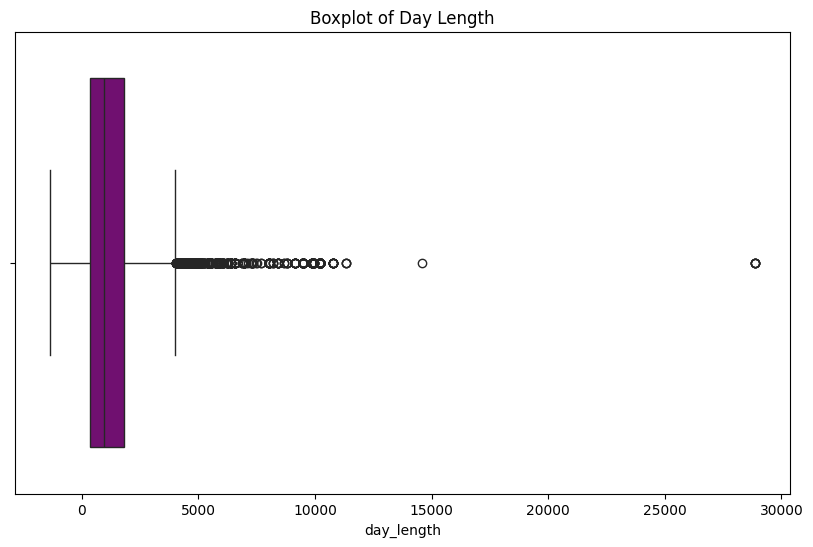

In [13]:
# Check for outliers in day_length
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['day_length'], color='purple')
plt.title('Boxplot of Day Length')
plt.show()

In [14]:
# cap at maximum feasible day_length
max_possible_days = (2026 - 1980) * 365 + 11  # includes leap years
df['day_length'] = df['day_length'].clip(upper=max_possible_days)

In [15]:
# Remove any possible negative day_length values
df = df[df['day_length'] >= 0]

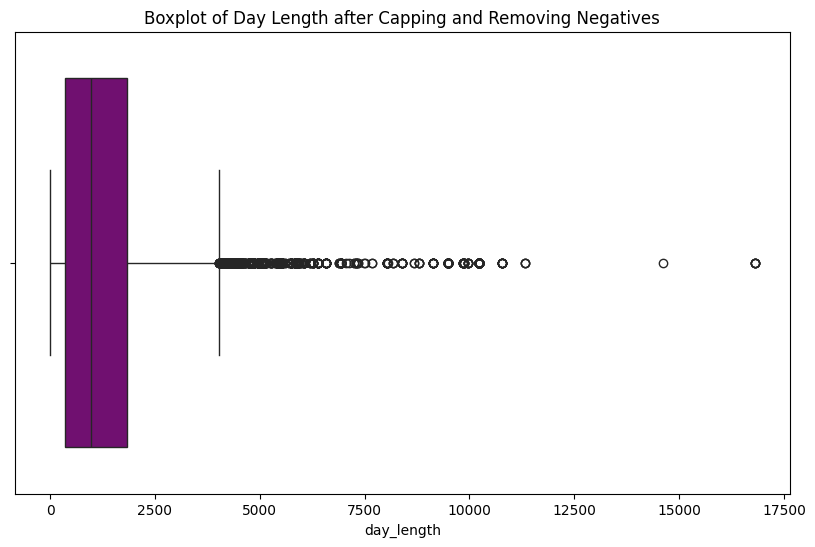

In [16]:
# Check for outliers in day_length
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['day_length'], color='purple')
plt.title('Boxplot of Day Length after Capping and Removing Negatives')
plt.show()

In [17]:
# Log transform day_length to reduce skewness
df['day_length_log'] = np.log1p(df['day_length'])

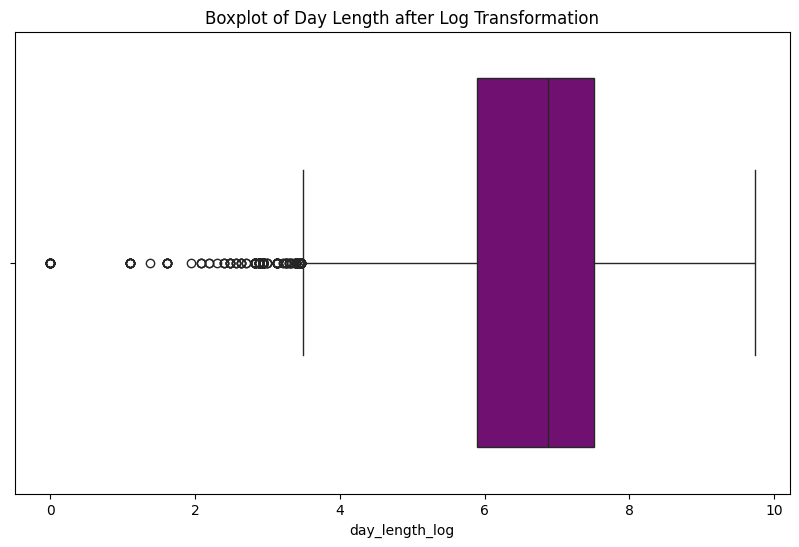

In [18]:
# Check for outliers in day_length
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['day_length_log'], color='purple')
plt.title('Boxplot of Day Length after Log Transformation')
plt.show()

#### 4. Handling missing values

The dataset contains missing values in several columns, particularly in sector-related variables such as `sector_code`, `sector_group`, and `sector_percent`. The `description` column also has some missing values. After conducting an analysis of the missing data patterns using visualizations like missingness matrices and heatmaps, it is discovered that these missing values followed a **Missing At Random `(MAR)`** pattern.

Thus, the methods chosen to handle these missing values are as follows:
* For the categorical sector columns (`sector_code` and `sector_group`), missing values are replaced with a new category labeled "Unknown". This approach preserves the information that the data was missing while allowing the model to learn from this category.
* For the numerical `sector_percent` column, missing values are filled with 0. This assumes that if the sector information is missing, the project does not allocate any percentage to that sector.
* For the `description` column, missing values are replaced with an empty string. This allows the text data to be processed without introducing bias from imputed text.

In [19]:
# Check for sum of missing values on each column
df.isna().sum().sort_values(ascending=False) 

sector_code        2337
sector_group       1128
sector_percent     1124
description         130
title                 0
slug                  0
reporting_ref         0
funder_ref            0
aid                   0
reporting             0
day_length            0
day_end               0
day_start             0
status_code           0
spend_eur             0
commitment            0
spend                 0
commitment_eur        0
commitment_cad        0
spend_gbp             0
commitment_gbp        0
flags                 0
spend_cad             0
country_code          0
country_percent       0
day_length_log        0
dtype: int64

<Axes: >

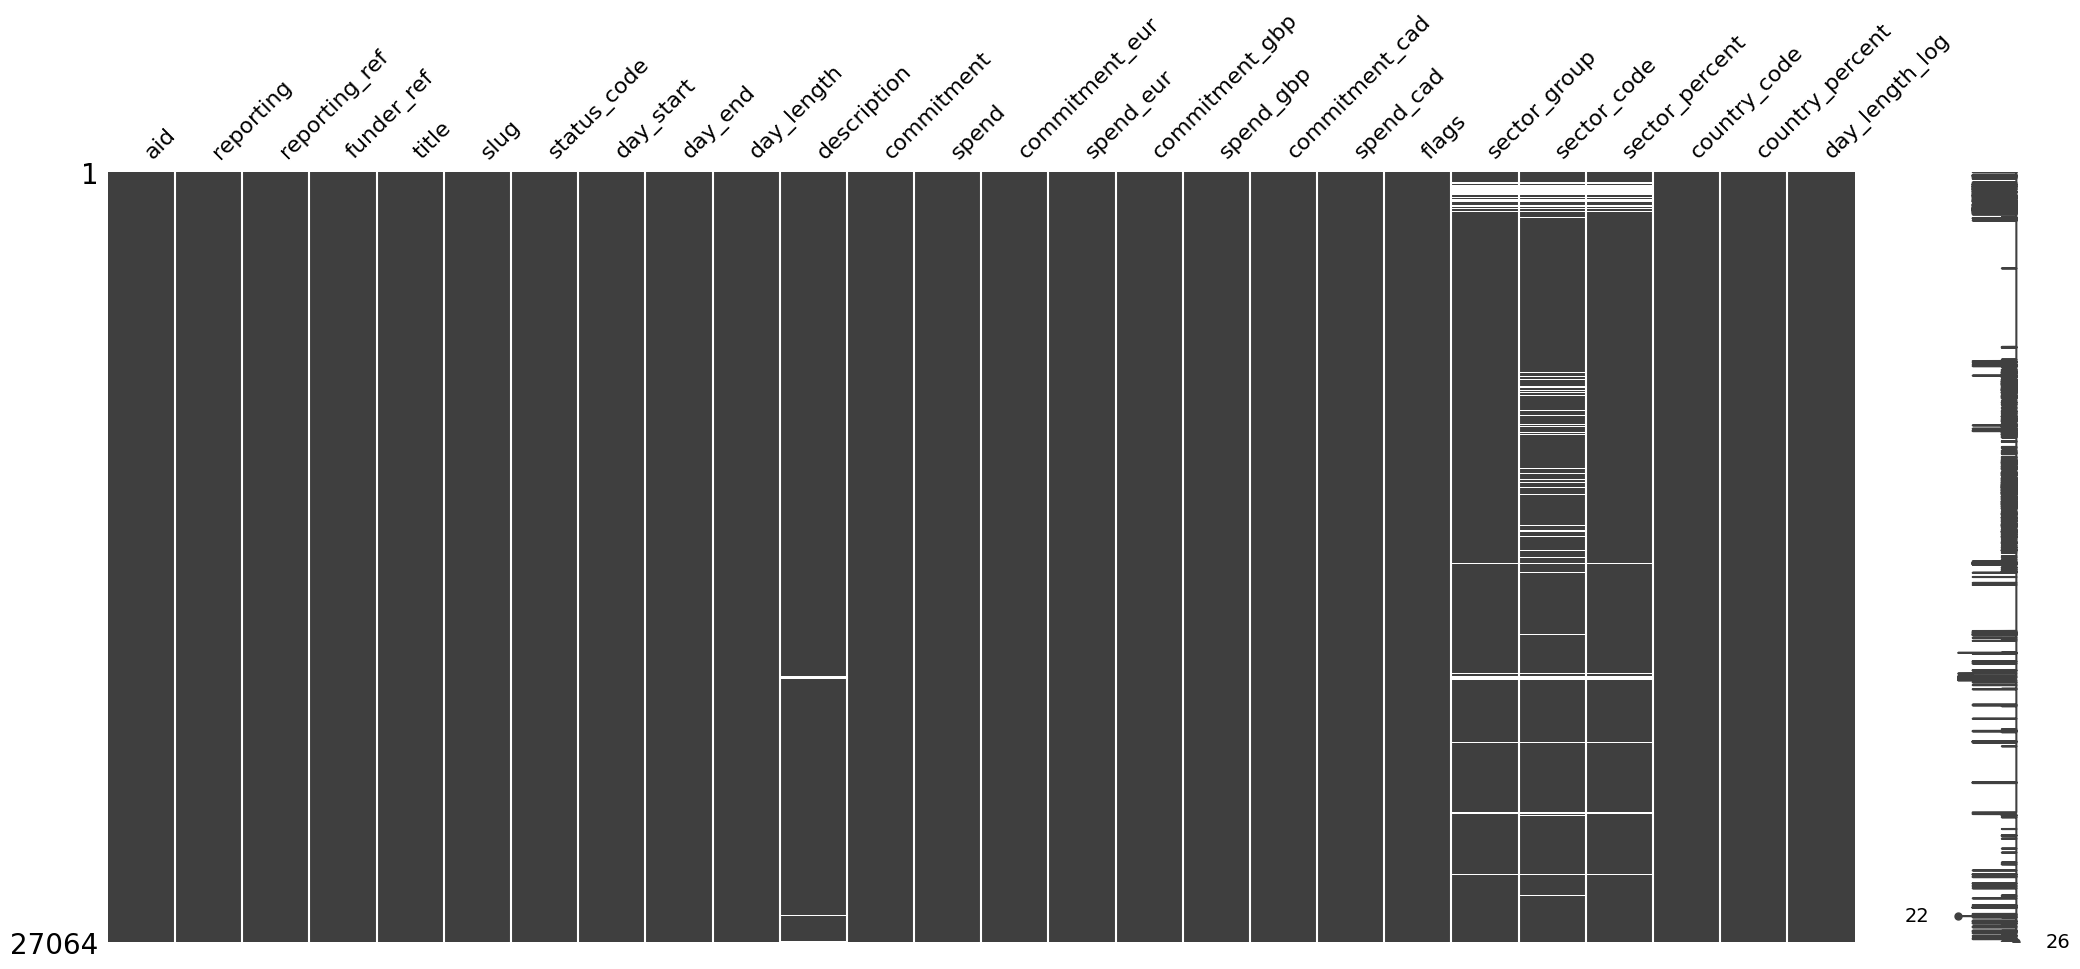

In [20]:
# Check for type of missingness
# Missingness matrix
msno.matrix(df)

<Axes: >

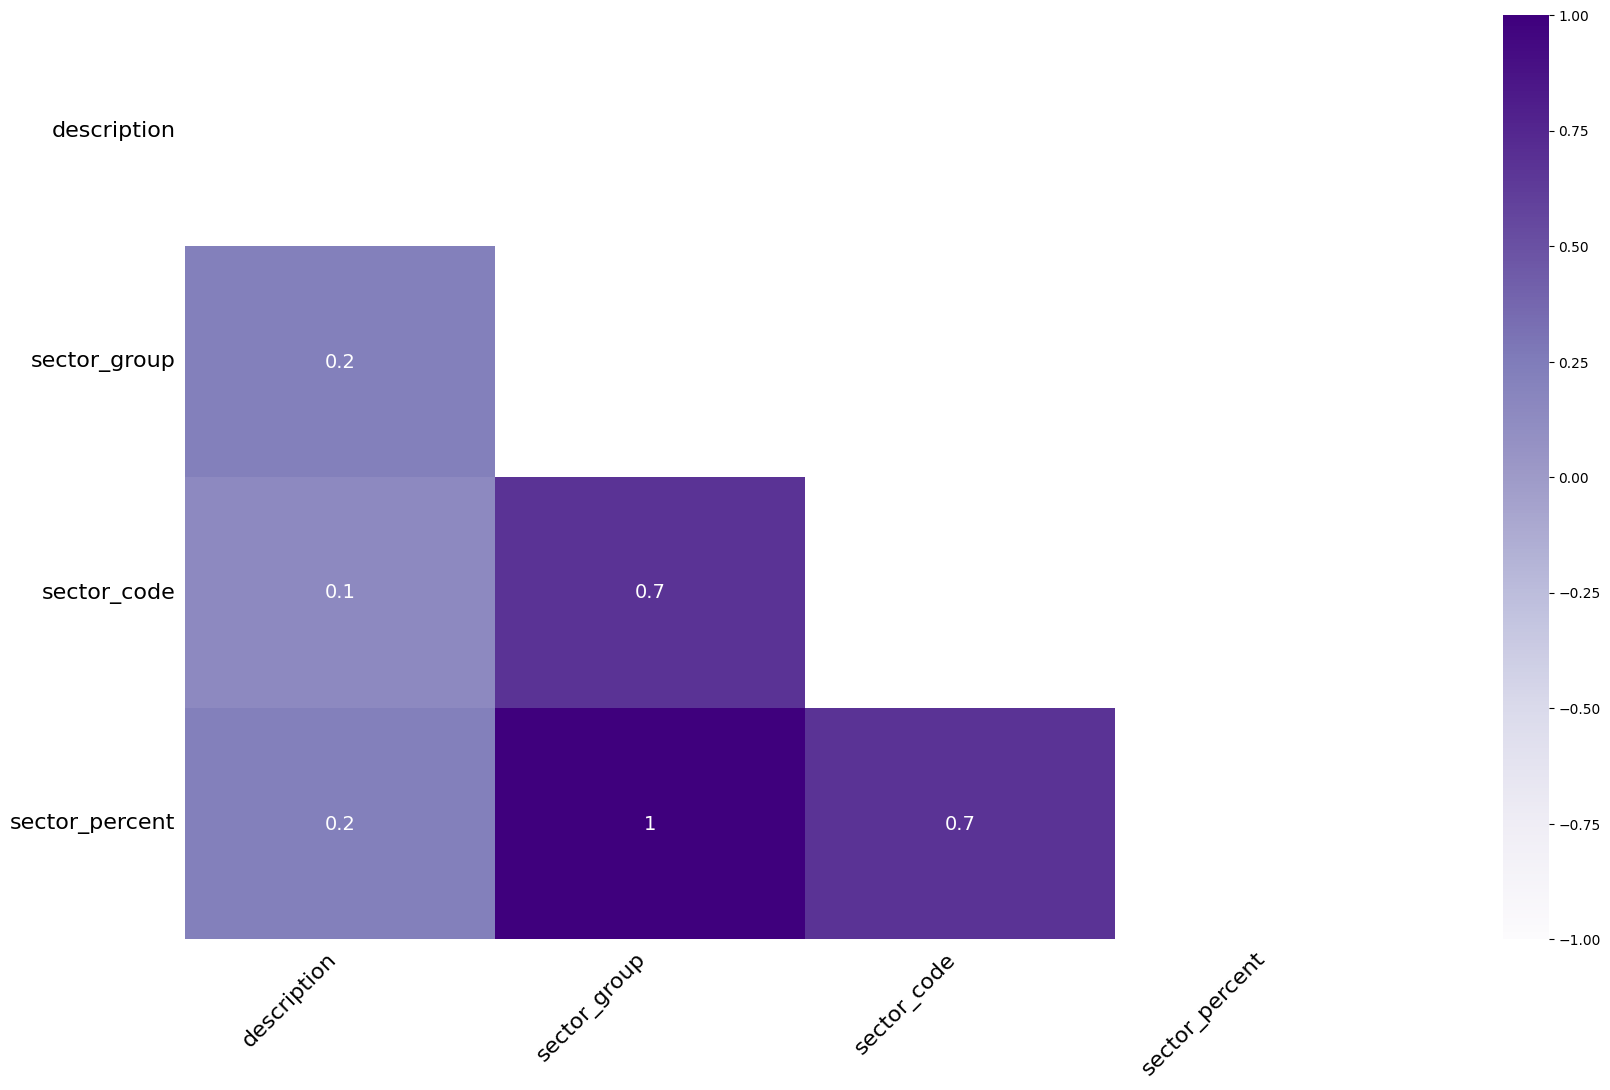

In [21]:
# Missingness heatmap
msno.heatmap(df, cmap="Purples")

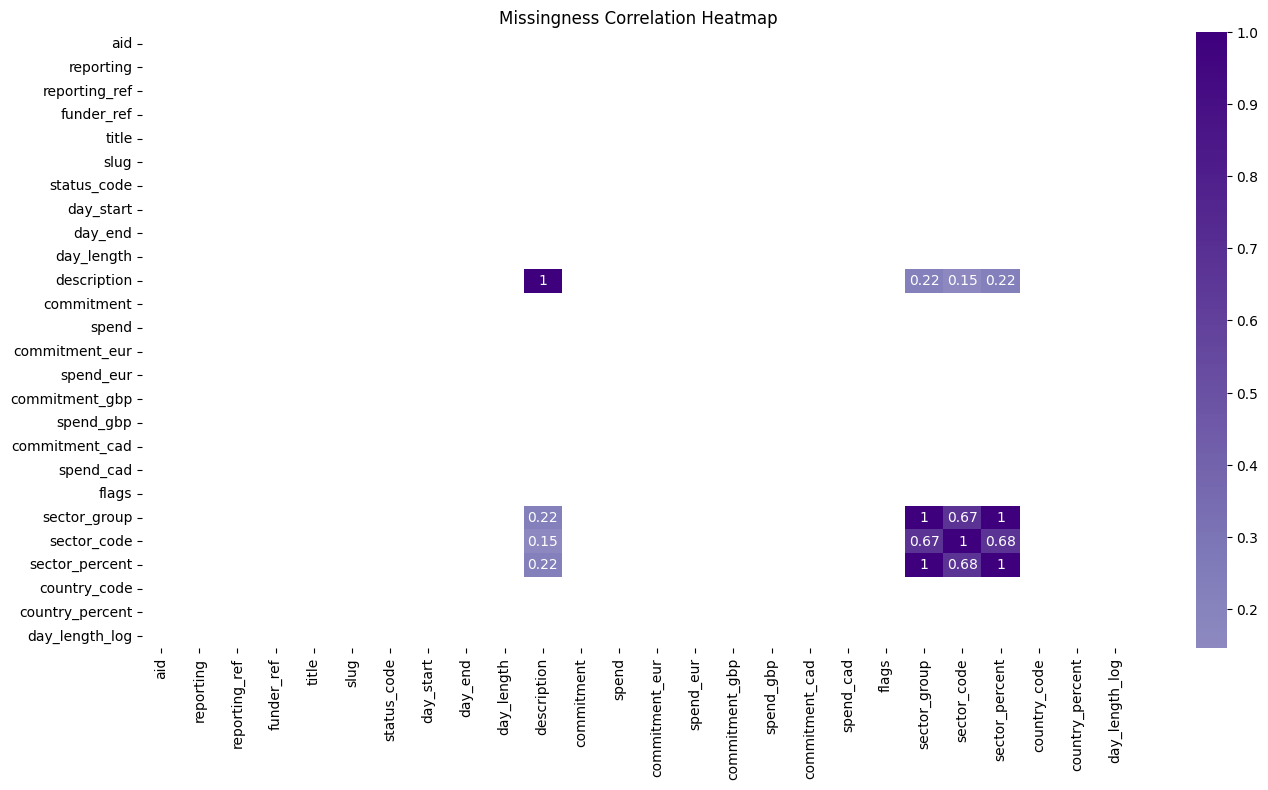

In [22]:
# Get correlation of missingness with other columns
missing_corr = df.isna().corr()

plt.figure(figsize=(16, 8))
sns.heatmap(missing_corr, cmap="Purples", center=0, annot=True)
plt.title("Missingness Correlation Heatmap")
plt.show()

In [23]:
# Create a missing indicator for the sector_code column
df["sector_missing"] = df["sector_code"].isna().astype(int)

In [24]:
# Replace the categorical sector columns' missing values with 'Unknown'
df["sector_code"] = df["sector_code"].fillna("Unknown")
df["sector_group"] = df["sector_group"].fillna("Unknown")

In [25]:
# Replace missing values in sector_percent with 0
df["sector_percent"] = df["sector_percent"].fillna(0)

In [26]:
# Replace missing values in description with empty string
df["description"] = df["description"].fillna("")

In [27]:
# Check for sum of missing values on each column
df.isna().sum().sort_values(ascending=False) 

aid                0
reporting          0
reporting_ref      0
funder_ref         0
title              0
slug               0
status_code        0
day_start          0
day_end            0
day_length         0
description        0
commitment         0
spend              0
commitment_eur     0
spend_eur          0
commitment_gbp     0
spend_gbp          0
commitment_cad     0
spend_cad          0
flags              0
sector_group       0
sector_code        0
sector_percent     0
country_code       0
country_percent    0
day_length_log     0
sector_missing     0
dtype: int64

#### 5. Convert the columns types to appropriate types

Some numeric columns have the type `object`, these columns include **commitment**, **spend**, **commitment_eur**, **spend_eur**, **commitment_gbp**, **spend_gbp**, **commitment_cad**, **spend_cad**, **sector_percent**, and **country_percent**. They are all converted to `float`. This ensures that numerical operations and analyses can be performed correctly on these columns.

In [28]:
# Check current types
df.dtypes

aid                        object
reporting                  object
reporting_ref              object
funder_ref                 object
title                      object
slug                       object
status_code                object
day_start          datetime64[ns]
day_end            datetime64[ns]
day_length                float64
description                object
commitment                 object
spend                      object
commitment_eur             object
spend_eur                  object
commitment_gbp             object
spend_gbp                  object
commitment_cad             object
spend_cad                  object
flags                      object
sector_group               object
sector_code                object
sector_percent             object
country_code               object
country_percent            object
day_length_log            float64
sector_missing              int64
dtype: object

In [29]:
# Convert the numeric columns to appropriate types
num_cols = [
    "commitment", "spend",
    "commitment_eur", "spend_eur",
    "commitment_gbp", "spend_gbp",
    "commitment_cad", "spend_cad",
    "sector_percent", "country_percent", "flags"
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
# Check updated types
df.dtypes

aid                        object
reporting                  object
reporting_ref              object
funder_ref                 object
title                      object
slug                       object
status_code                object
day_start          datetime64[ns]
day_end            datetime64[ns]
day_length                float64
description                object
commitment                float64
spend                     float64
commitment_eur            float64
spend_eur                 float64
commitment_gbp            float64
spend_gbp                 float64
commitment_cad            float64
spend_cad                 float64
flags                       int64
sector_group               object
sector_code                object
sector_percent            float64
country_code               object
country_percent           float64
day_length_log            float64
sector_missing              int64
dtype: object

#### 6. Handle duplicates

The number of duplicated rows found is 34. These duplicates are removed to ensure data quality and integrity. 

In [30]:
# Check for duplicates
duplicate_rows = df[df.duplicated()]
# Number of duplicated rows
duplicate_rows.shape[0]

34

In [31]:
# Drop duplicates
df = df.drop_duplicates()

In [32]:
# Check for duplicates
duplicate_rows = df[df.duplicated()]
# Number of duplicated rows
duplicate_rows.shape[0]

0

#### 7. Create text feature
The `title` and `slug` columns are combined to create a new text feature called `text`. This new feature will be used for natural language processing (NLP) analysis to extract insights from the project descriptions and sector tags. By combining these two columns, we can capture more contextual information about the projects, which may improve the performance of predictive models that utilize textual data.

In [44]:
# Create text feature
df['text'] = df['title'] + " " + df['slug']
df[['text']].head()

,text
0,Energising Development (ENDEV4) rvo-01
1,Care for babies & empower young mothers in Nai...
2,Voice Programme costs Hivos Kenya onl-activity
3,Equip a rural Kenyan library with a computer l...
4,Pilot 2g@there OS (TGOS) rvo-01


#### 8. Cost efficiency
There are some negative values in the `spend` column. These negative values are likely due to financial adjustments such as refunds or accounting corrections rather than actual project expenditures. These negative values are identified and removed to maintain the integrity of the cost efficiency analysis.

A new feature called `efficiency` is created to measure cost efficiency, defined as the ratio of actual spending to project duration (in days). This is calculated as `spend / (day_length + 1)` to avoid division by zero. Additionally, a log transformation of the efficiency metric is created as `efficiency_log` to reduce skewness and improve model performance when predicting cost efficiency.

In [52]:
df[df['spend'] < 0][['sector_group', 'spend']].head()

,sector_group,spend
1201,Business & Other Services,-11440321.0
1202,Business & Other Services,-11440321.0
1403,Administrative Costs of Donors,-2663.0
1610,Industry,-9548623.0
1611,Industry,-9548623.0


In [53]:
df[df['spend'] < 0][['sector_group', 'spend']].shape

(146, 2)

In [54]:
# Create a clean dataset for efficiency modeling
df = df[df['spend'] >= 0].copy()

# Cost efficiency
df['efficiency'] = df['spend'] / (df['day_length'] + 1)
df['efficiency_log'] = np.log1p(df['efficiency'])

### Exploratory Data Analysis (EDA)

#### Descriptive Analytics

1. Distribution of Project Durations

The raw distribution of project duration is **strongly right-skewed**, with most of the projects lasting a **short to medium** time and a small number extending for **many years**.After applying a **log transformation** to the `day_length` variable, the distribution becomes **more symmetric**, revealing underlying patterns and reducing the influence of extreme long-runniing projects.

Project duration is **highly variable** and **non-normal** in its raw form. The log transformation helps to stabilise variance and makes the data more suitable for modeling.

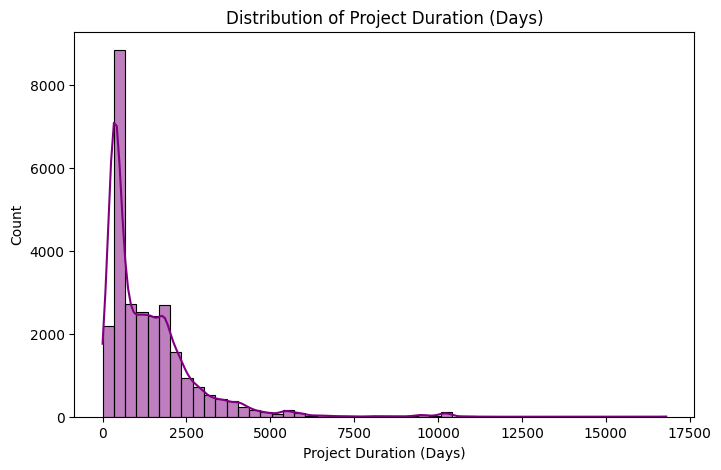

In [33]:
# Distribution of Project Durations
plt.figure(figsize=(8,5))
sns.histplot(df['day_length'], bins=50, kde=True, color='purple')
plt.title("Distribution of Project Duration (Days)")
plt.xlabel("Project Duration (Days)")
plt.ylabel("Count")
plt.show()

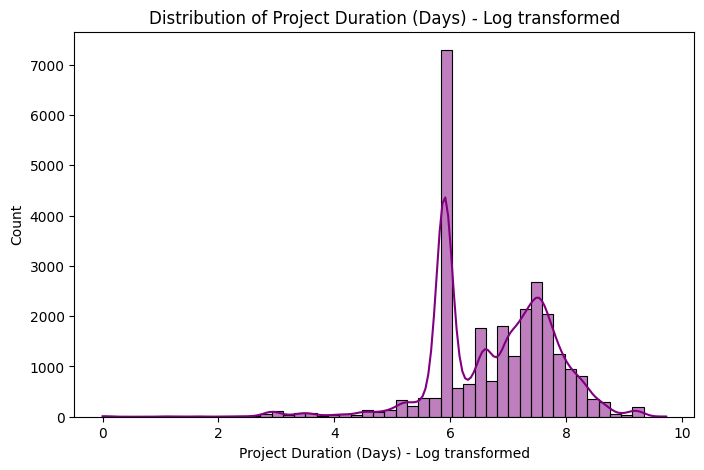

In [34]:
# Distribution of Project Durations - Log transformed
plt.figure(figsize=(8,5))
sns.histplot(df['day_length_log'], bins=50, kde=True, color='purple')
plt.title("Distribution of Project Duration (Days) - Log transformed")
plt.xlabel("Project Duration (Days) - Log transformed")
plt.ylabel("Count")
plt.show()

2. Project Status Distribution

The status_codes were explored and found to be  **highly imbalanced**, with a majority of the projects in `Implementation`, `Finalisation` and `Closed` states. 

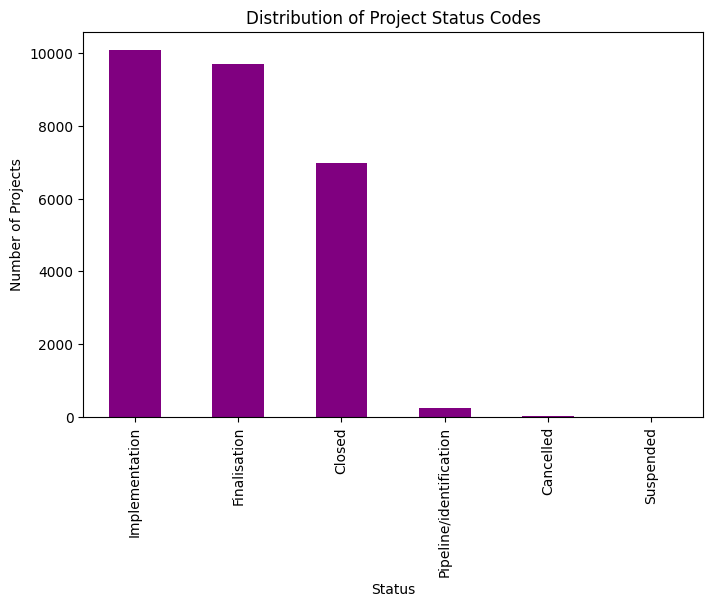

In [35]:
# Distribution of Project Status Codes
df['status_code'].value_counts().plot(kind='bar', figsize=(8,5), color='purple')
plt.title("Distribution of Project Status Codes")
plt.xlabel("Status")
plt.ylabel("Number of Projects")
plt.show()

3. Top Reporting Organisations by Number of Projects

A small number of donors; most notably **USAID, Sweden, and CGIAR**, account for a large share of all projects. Aid delivery in Kenya is **donor concentrated**, meaning the reporting organisation is likely a **strong predictive feature** for both project duration and completion outcomes.

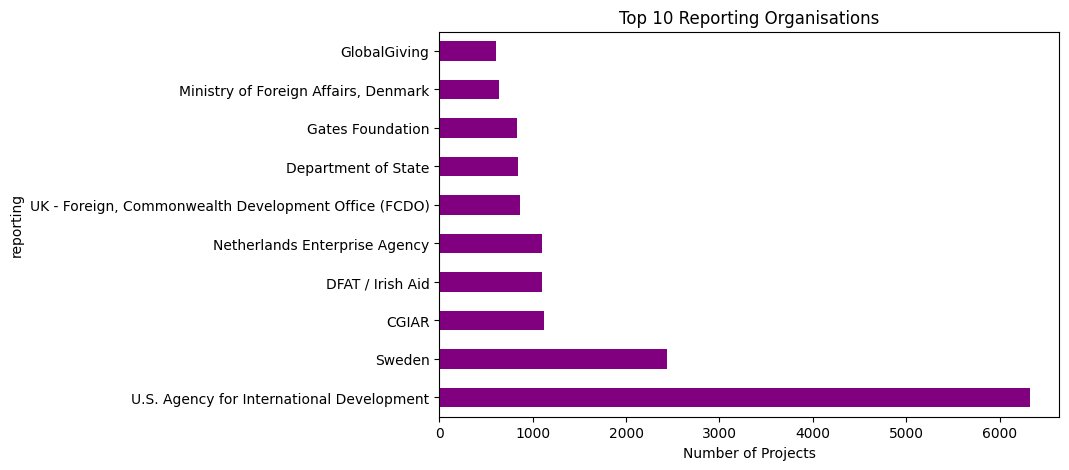

In [36]:
# Top 10 Reporting Organisations
df['reporting'].value_counts().head(10).plot(kind='barh', figsize=(8,5), color='purple')
plt.title("Top 10 Reporting Organisations")
plt.xlabel("Number of Projects")
plt.show()

4. Sectorwise Distribution of Projects

Projects are heavily concentrated in **Governance, Agriculture, and Health-related sectors**, with fewer projects in other sectors. Sector type plays a significant role in project behaviour, making it an immportant categorical feature for modeling.

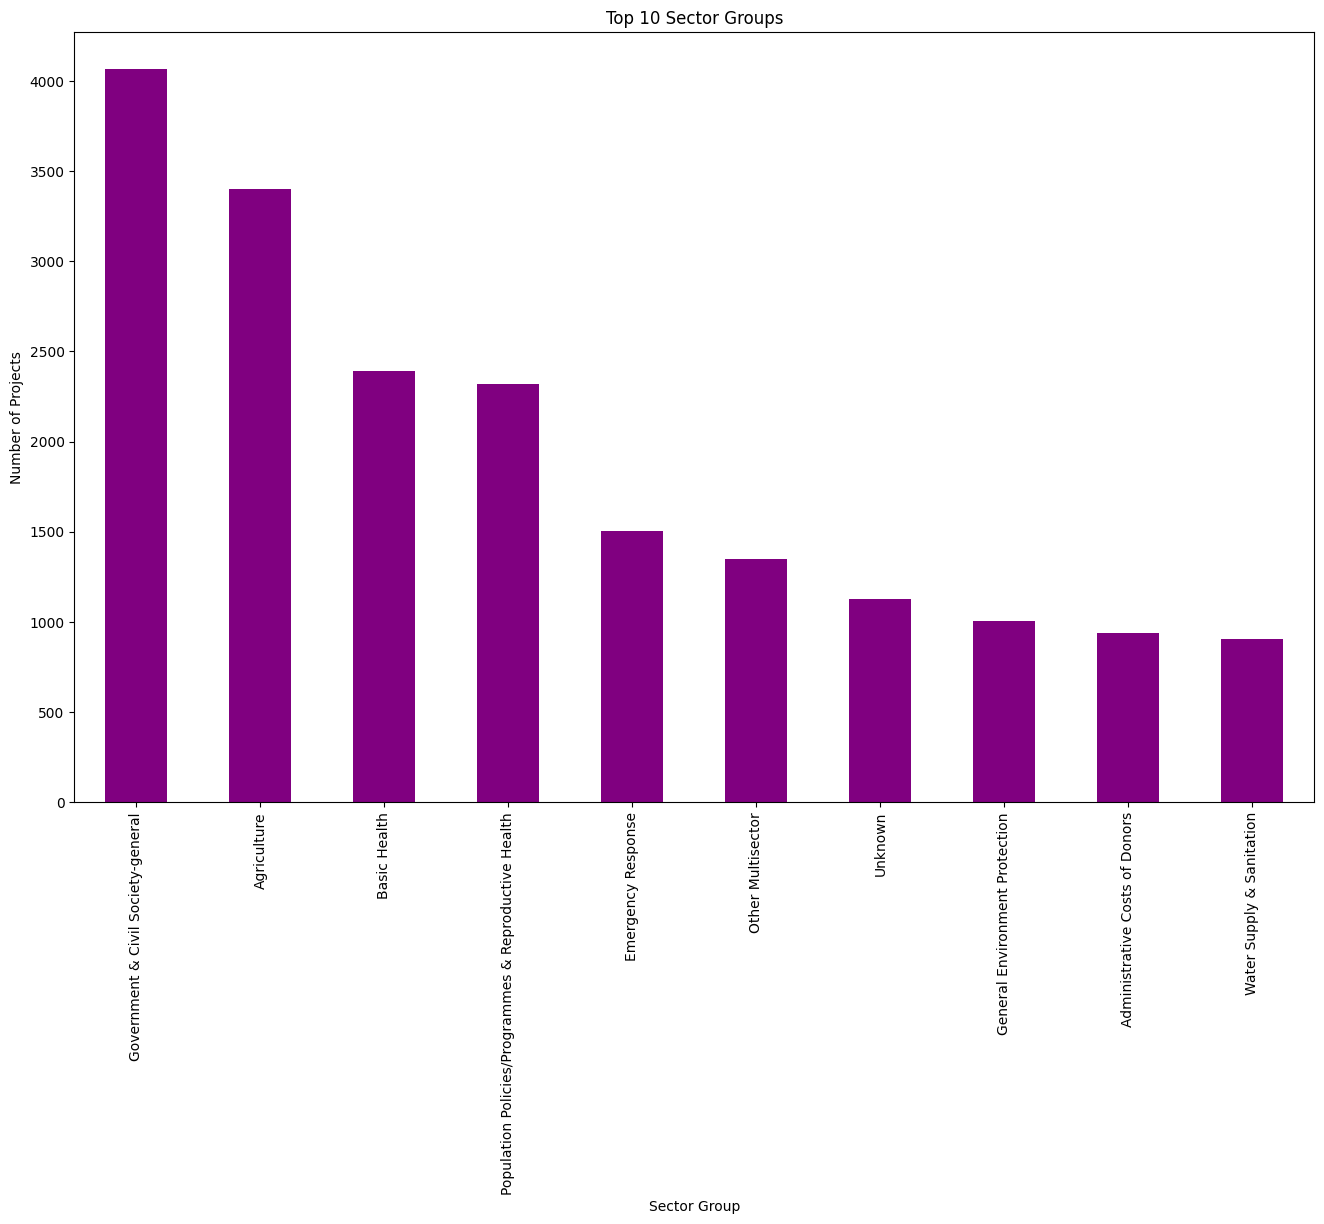

In [37]:
# Sectorwise Distribution of Projects
df['sector_group'].value_counts().head(10).plot(kind='bar', figsize=(16,10), color='purple')
plt.title("Top 10 Sector Groups")
plt.ylabel("Number of Projects")
plt.xlabel("Sector Group")
plt.show()

5. Start year trend of Projects

The number of projects started per year shows a gradual increase from late 1990s, a sharp rise after 2010 and a peak around 2018-2019, followed by a slight decline after 2020.

Aid activity in Kenya follows **strong temporal trends**, likely influenced by funding cycles, policy changes, external shocks, and global events. This shows the importance of  **time-based features** for predictive modeling.

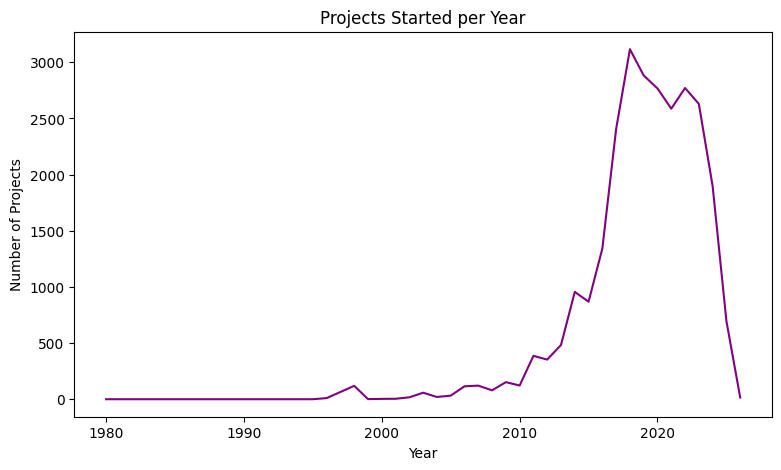

In [38]:
# Start year trend of Projects
df['start_year'] = pd.to_datetime(df['day_start']).dt.year

df['start_year'].value_counts().sort_index().plot(figsize=(9,5), color='purple')
plt.title("Projects Started per Year")
plt.xlabel("Year")
plt.ylabel("Number of Projects")
plt.show()

#### Diagnostic Analytics

1. Project Duration by Status

Ongoing and completed projects (Implementation, Closed, Finalization) show **much longer and more variable durations** in comparison to Cancelled or Suspended projects. This indicates that **long duration is not inherently negative** but context-dependent.

Failed or stalled projects tend to have **shorter more tightly clustered durations**, suggesting **early termination rather than prolonged inefficiency**.

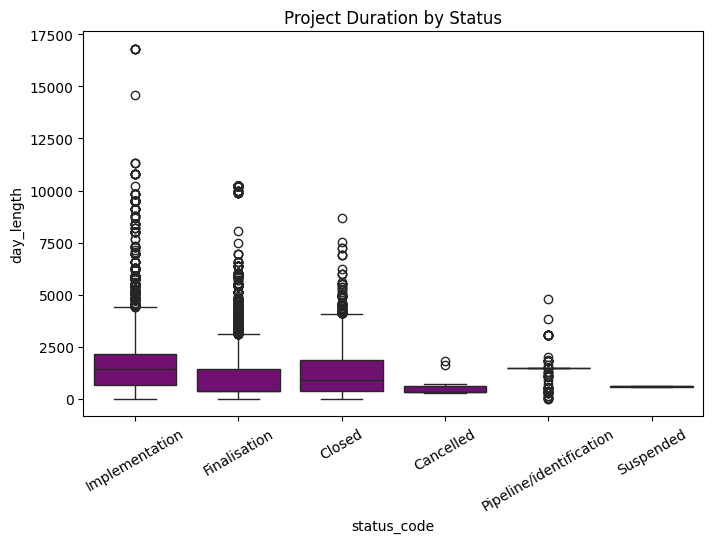

In [39]:
# Project Duration by Status
plt.figure(figsize=(8,5))
sns.boxplot(x='status_code', y='day_length', data=df, color='purple')
plt.title("Project Duration by Status")
plt.xticks(rotation=30)
plt.show()

2. Sector-wise Project Duration

Sectors such as **Basic Health and Agriculture** show **longer and more dispersed project durations**, while **Emergency Response** projects are shorter and more time-bound.

Sector introduces **structural time bias**. Sector-aware models (or sector embeddings) will outperform generic duration models.

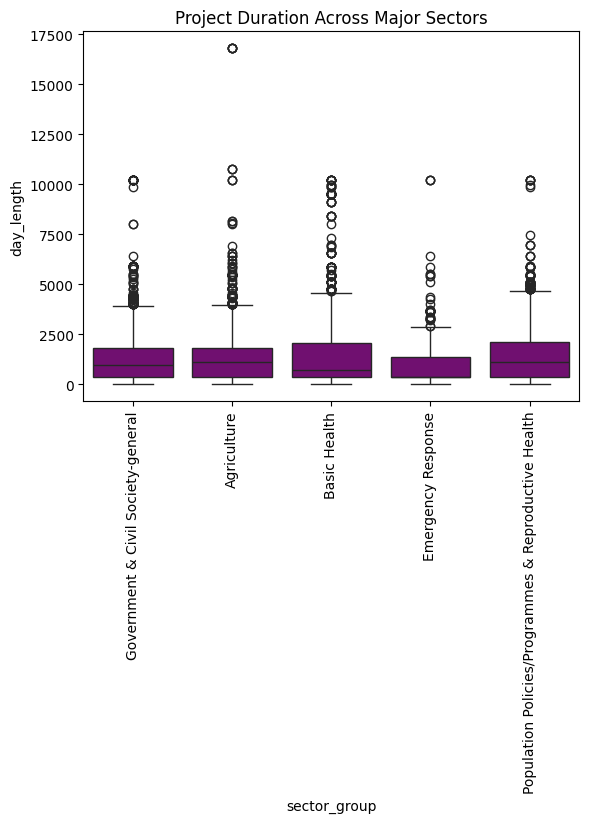

In [40]:
# Project Duration Across Major Sectors
top_sectors = df['sector_group'].value_counts().head(5).index

sns.boxplot(
    data=df[df['sector_group'].isin(top_sectors)],
    x='sector_group',
    y='day_length',
    color='purple'
)
plt.title("Project Duration Across Major Sectors")
plt.xticks(rotation=90)
plt.show()

3. Financial Spend vs Project Duration

The relationship between **total spend and duration is weak and noisy**. High-spend projects exist at both short and long durations.

Financial variables alone are **inefficient predictors of duration**. This justifies incorporating **non-financial features**.

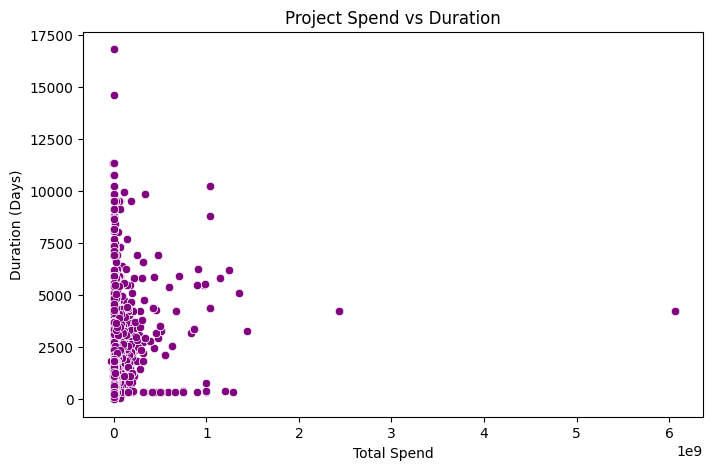

In [41]:
# Project Spend vs Duration
plt.figure(figsize=(8,5))
sns.scatterplot(x='spend', y='day_length', data=df, color='purple')
plt.title("Project Spend vs Duration")
plt.xlabel("Total Spend")
plt.ylabel("Duration (Days)")
plt.show()

4. Correlation Matrix of Numerical Features

Spending and commitment variables are **highly collinear**(Redundant). Failure/stalling is weakly correlated with numeric features, indicating it is driven more by **categorical/textual factors**. Strong negative correlation between **start year and duration** suggests **more recent projects are shorter**, likely due to evolving project management practices.

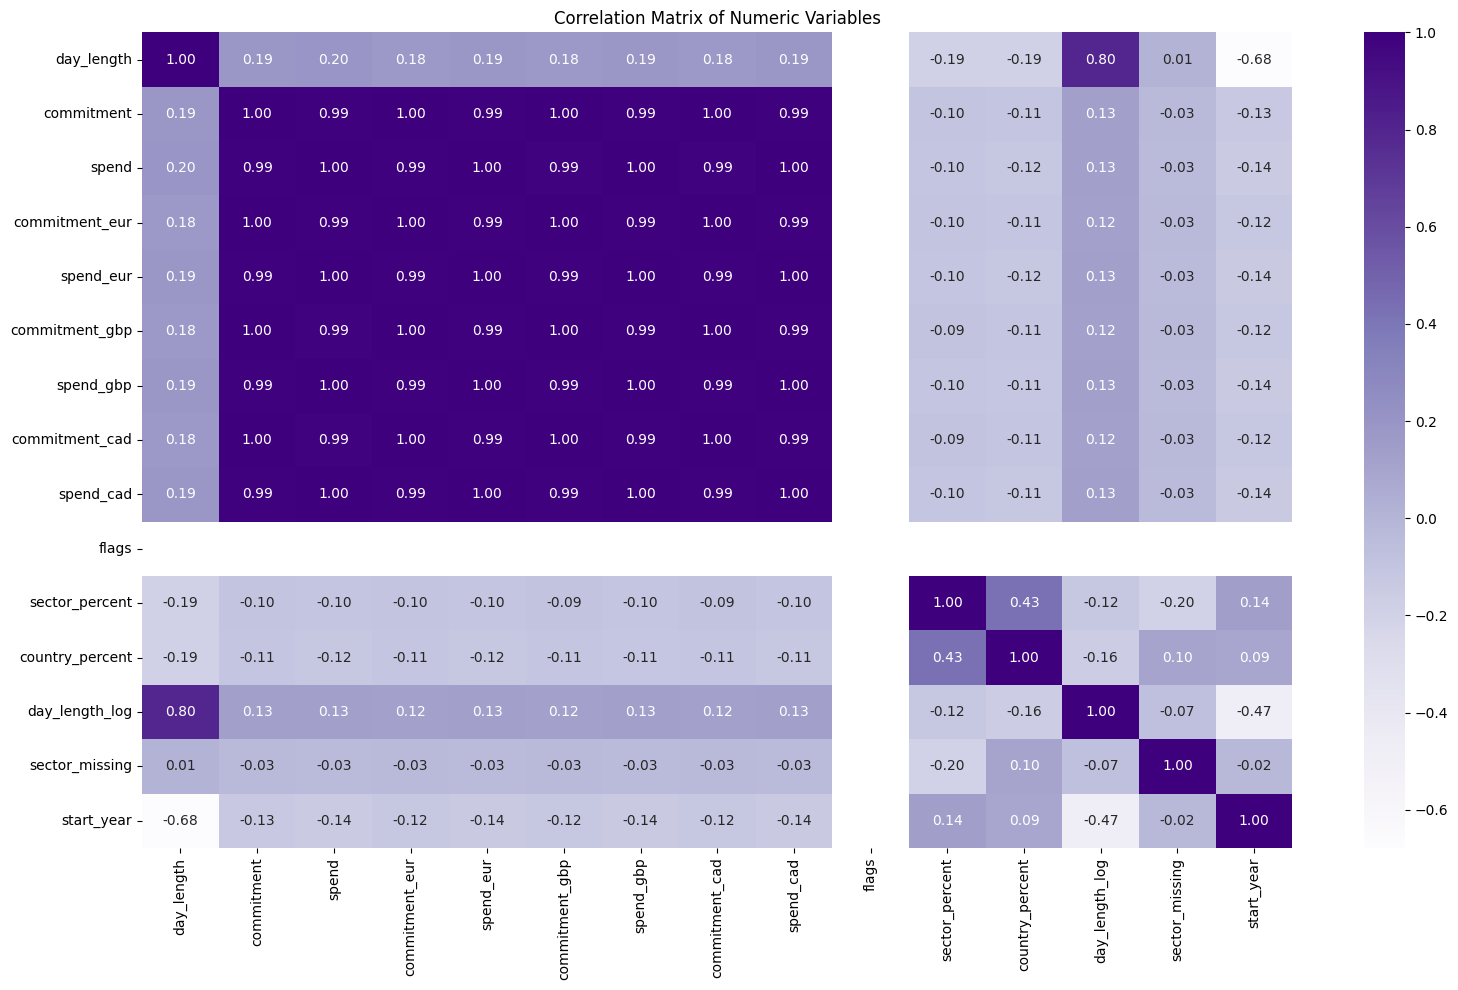

In [42]:
# Automatically select numeric columns
numeric_cols = df.select_dtypes(include='number')

plt.figure(figsize=(16, 10))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Purples', fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()


5. Efficiency by Sector

**Development Food Assistance** is the most efficient sector, but there are only a few others that are as efficient. Most other sectors are much less efficient, which means that the distribution is not even and is instead driven by factors that are specific to each sector.

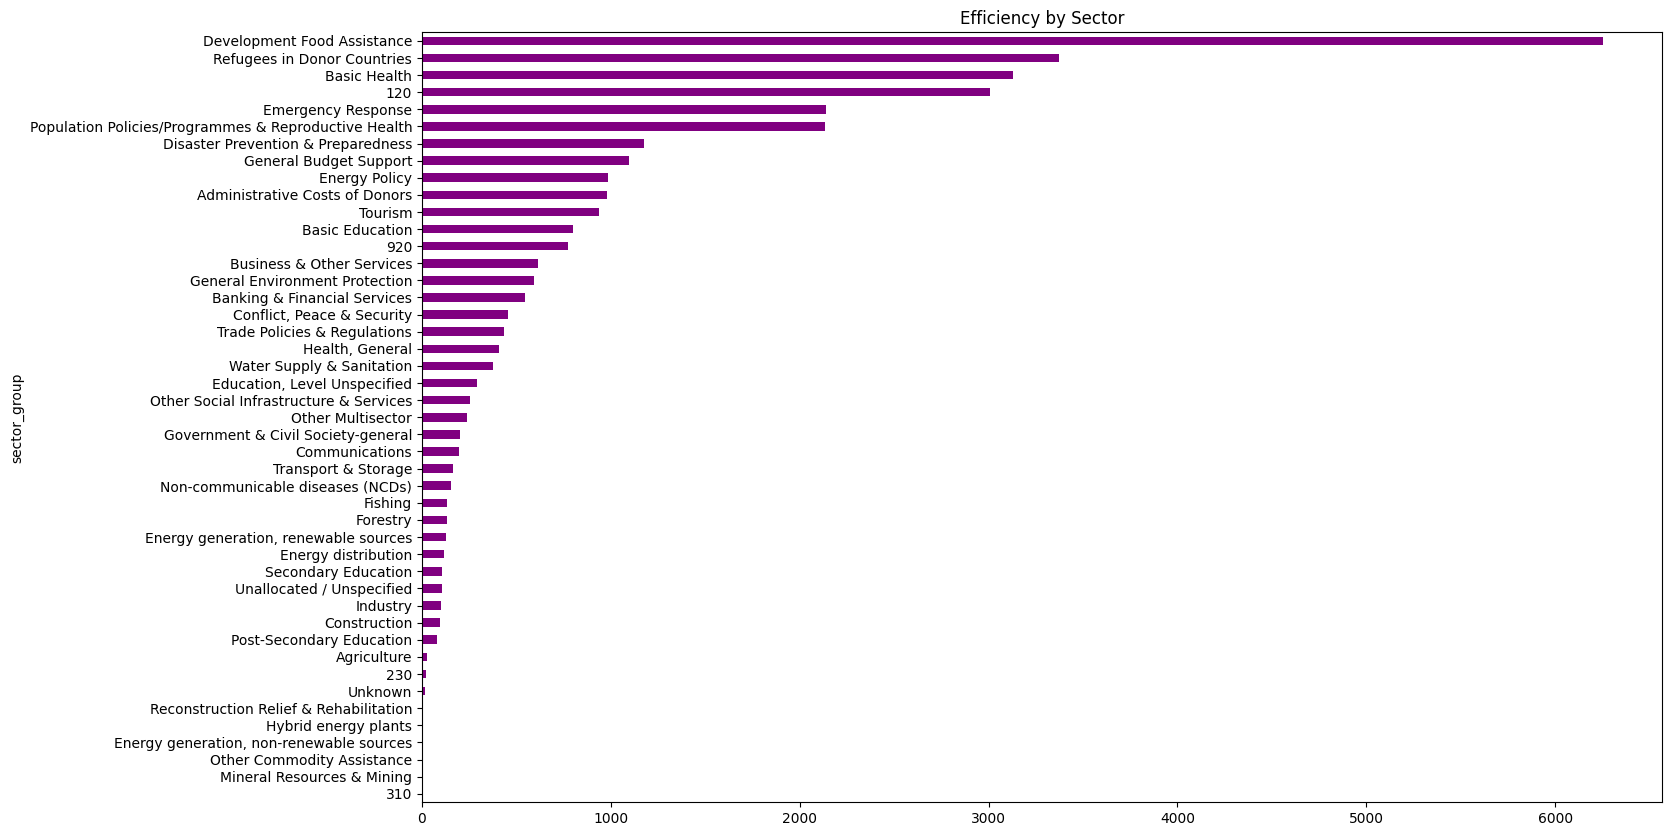

In [55]:
df.groupby('sector_group')['efficiency'].median().sort_values().plot(kind='barh', figsize=(16,10), color='purple')
plt.title("Efficiency by Sector")
plt.show()

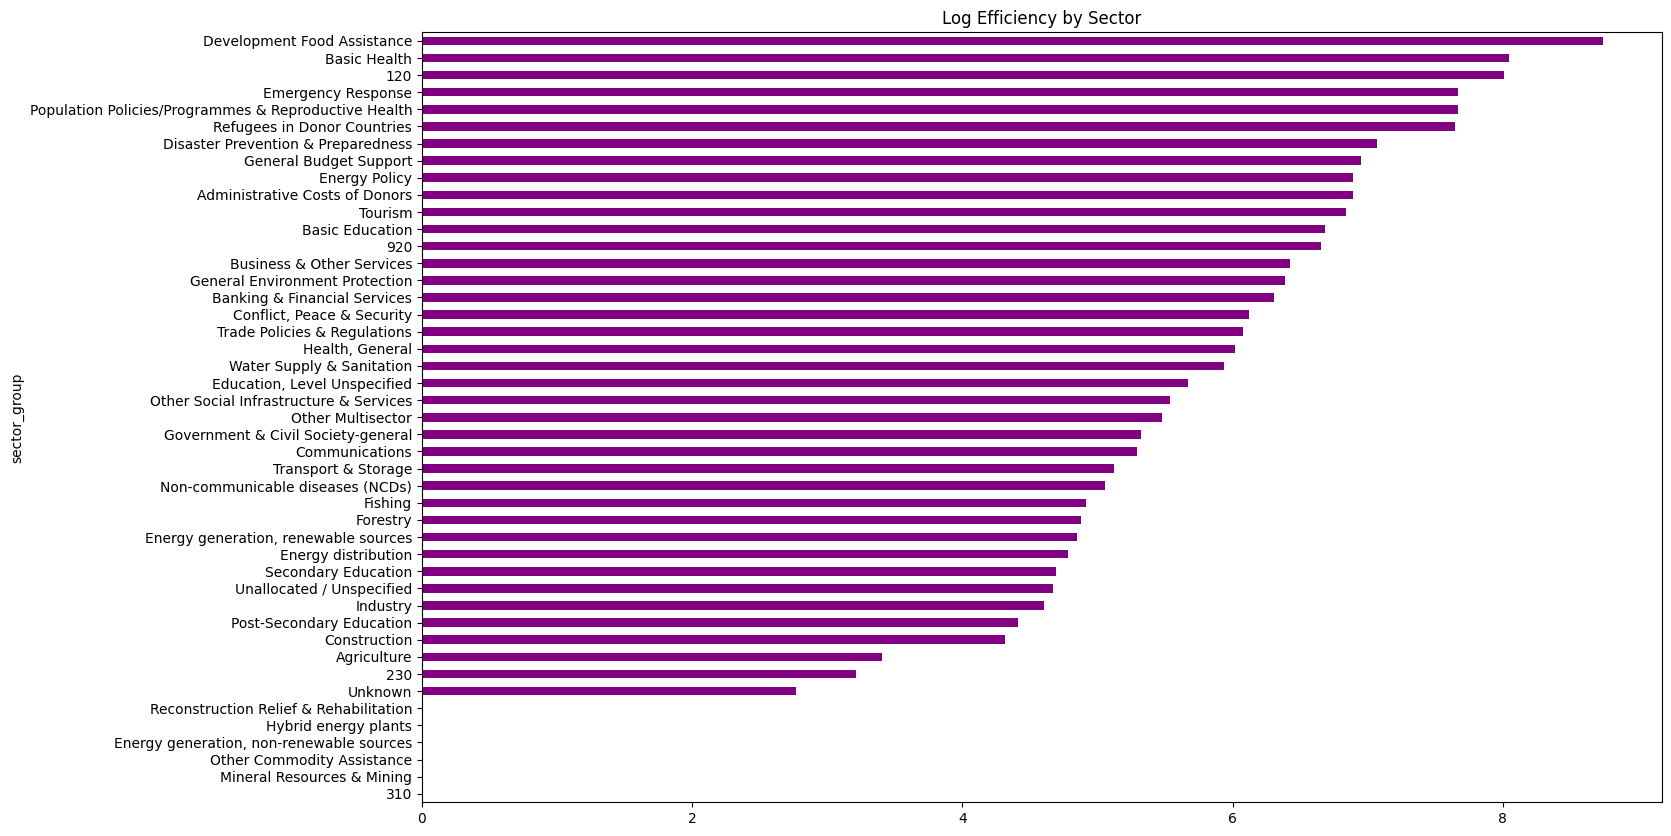

In [56]:
df.groupby('sector_group')['efficiency_log'].median().sort_values().plot(kind='barh', figsize=(16,10), color='purple')
plt.title("Log Efficiency by Sector")
plt.show()

### Feature Preprocessing and Engineering

In [58]:
# Time features
df['start_year'] = df['day_start'].dt.year
df['start_month'] = df['day_start'].dt.month

features = [
    'text',
    'reporting',
    'sector_group',
    'start_year',
    'start_month',
    'sector_percent',
    'country_percent'
]

X = df[features]
y_duration = df['day_length_log']
y_efficiency = df['efficiency_log']

In [ ]:
# Preprocessor
preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=500), 'text'),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['reporting','sector_group']),
    ('num', StandardScaler(), ['start_year','start_month','sector_percent','country_percent'])
])

#### Train-test split

In [64]:
# Train-test split
X_train, X_test, y_train_dur, y_test_dur = train_test_split(X, y_duration, test_size=0.2, random_state=42)

X_train_eff, X_test_eff, y_train_eff, y_test_eff = train_test_split(X, y_efficiency, test_size=0.2, random_state=42)

#### Base Models

In [ ]:
# Base models for comparison
models = {
    "RandomForest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
    "LightGBM": LGBMRegressor()
}

#### Training and Comparison of duration models

The three baseline models were evaluated using RMSE on the log-transformed project duration. The **Random Forest model performed best** with the lowest error (RMSE ≈ 0.448), followed by **XGBoost (RMSE ≈ 0.501)** and **LightGBM (RMSE ≈ 0.528)**. This suggests that Random Forest is better at capturing the underlying patterns in the data, possibly due to its robustness to noise and ability to handle nonlinear relationships effectively.

The relatively higher error in boosting models may indicate sensitivity to feature sparsity (especially from TF-IDF text features) or the need for further hyperparameter tuning. Overall, Random Forest provides the strongest baseline, and these results justify the need for **enhanced models (e.g., stacking)** to further improve predictive performance.


In [62]:
# Train and compare
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train_dur)
    preds = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_dur, preds))
    results[name] = rmse
    
    print(name, rmse)

RandomForest 0.44753209825885104
XGBoost 0.5009319930863722
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27668
[LightGBM] [Info] Number of data points in the train set: 21507, number of used features: 622
[LightGBM] [Info] Start training from score 6.756634
LightGBM 0.5277110474110406


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#### Enhanced model with stacking

The stacking model combines multiple base learners (e.g., Random Forest, XGBoost, LightGBM) to improve predictive performance by leveraging the strengths of each. The final **RMSE of 0.4415** is lower than all individual models tested earlier (RandomForest: 0.4475, XGBoost: 0.5009, LightGBM: 0.5277), indicating that the ensemble approach provides better accuracy in predicting project duration.

This improvement shows that different models capture different patterns in the data, and stacking effectively integrates these patterns into a stronger predictive model. The repeated LightGBM logs reflect cross-validation within the stacking process, ensuring robustness and reducing overfitting.

Overall, the stacking model demonstrates that **enhanced machine learning techniques outperform standalone algorithms**, aligning with the project requirement to improve baseline models through additional computational steps.


In [63]:
# Enhanced model
stack_model = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor()),
        ('xgb', XGBRegressor()),
        ('lgbm', LGBMRegressor())
    ],
    final_estimator=Ridge()
)

stack_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', stack_model)
])

stack_pipeline.fit(X_train, y_train_dur)
stack_preds = stack_pipeline.predict(X_test)

print("Stacking RMSE:", np.sqrt(mean_squared_error(y_test_dur, stack_preds)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029858 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27668
[LightGBM] [Info] Number of data points in the train set: 21507, number of used features: 622
[LightGBM] [Info] Start training from score 6.756634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23796
[LightGBM] [Info] Number of data points in the train set: 17205, number of used features: 615
[LightGBM] [Info] Start training from score 6.753277


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032961 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23760
[LightGBM] [Info] Number of data points in the train set: 17205, number of used features: 618
[LightGBM] [Info] Start training from score 6.755578


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23688
[LightGBM] [Info] Number of data points in the train set: 17206, number of used features: 617
[LightGBM] [Info] Start training from score 6.762512


...

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23790
[LightGBM] [Info] Number of data points in the train set: 17206, number of used features: 614
[LightGBM] [Info] Start training from score 6.756976


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Stacking RMSE: 0.4414904640413316


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#### Cost efficiency model

The cost efficiency regression model achieved an **RMSE of 1.7281**, which indicates the average prediction error between the model’s predicted efficiency values and the actual observed values. Compared to the project duration model, this error is relatively higher, suggesting that cost efficiency is a more complex and noisy target to predict.

This result is expected because cost efficiency is influenced by multiple interacting factors such as sector type, funding variability, reporting differences, and inconsistent spending patterns across projects. Unlike duration, which is more structurally defined, efficiency reflects financial and operational complexity, making it harder for the model to learn stable patterns.

Overall, while the model provides a reasonable baseline for estimating cost efficiency, there is still room for improvement through advanced feature engineering, outlier handling (especially negative spend cases), and potentially more robust ensemble methods.


In [65]:
# Cost efficiency model
eff_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor())
])

eff_pipeline.fit(X_train, y_train_eff)

eff_preds = eff_pipeline.predict(X_test_eff)

print("Efficiency RMSE:", np.sqrt(mean_squared_error(y_test_eff, eff_preds)))

Efficiency RMSE: 1.7281304931192774


#### Model Based Feature Importance

The plot shows that **most features have very low importance**, with only a few spikes standing out. This indicates that the model relies on a **small subset of features** to make predictions, while the majority contribute minimally. The presence of a few higher peaks suggests **key drivers of the model**, but overall importance values remain relatively small, implying **no single dominant feature** and a fairly distributed influence among the top predictors.

In [66]:
model = stack_pipeline.named_steps['model']

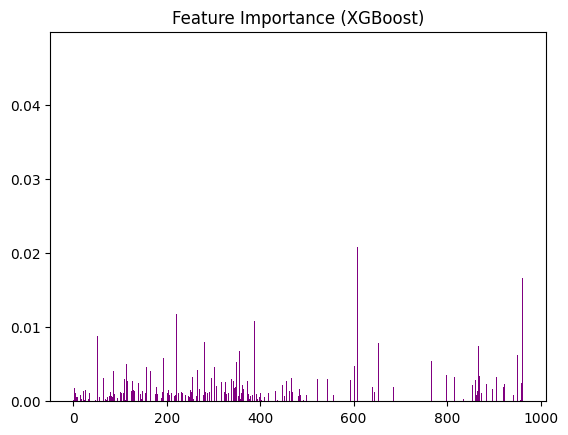

In [68]:
xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor())
])

xgb_pipe.fit(X_train, y_train_dur)

importances = xgb_pipe.named_steps['model'].feature_importances_

plt.bar(range(len(importances)), importances, color='purple')
plt.title("Feature Importance (XGBoost)")
plt.show()

#### SHAP Explanation

The SHAP plot provides a deeper view of **how features impact predictions**. Features like **Feature 961, 964, and 962** have the **largest impact**, as shown by their wider spread along the SHAP axis. The horizontal spread indicates the **magnitude of influence**, while the clustering around zero for many features shows **limited effect on predictions**.

Additionally, the mix of positive and negative SHAP values suggests that features can **both increase and decrease the model output**, depending on their values. The long tails (outliers) in some features indicate **strong effects for certain observations**, highlighting **non-linear relationships and variability in feature influence**.


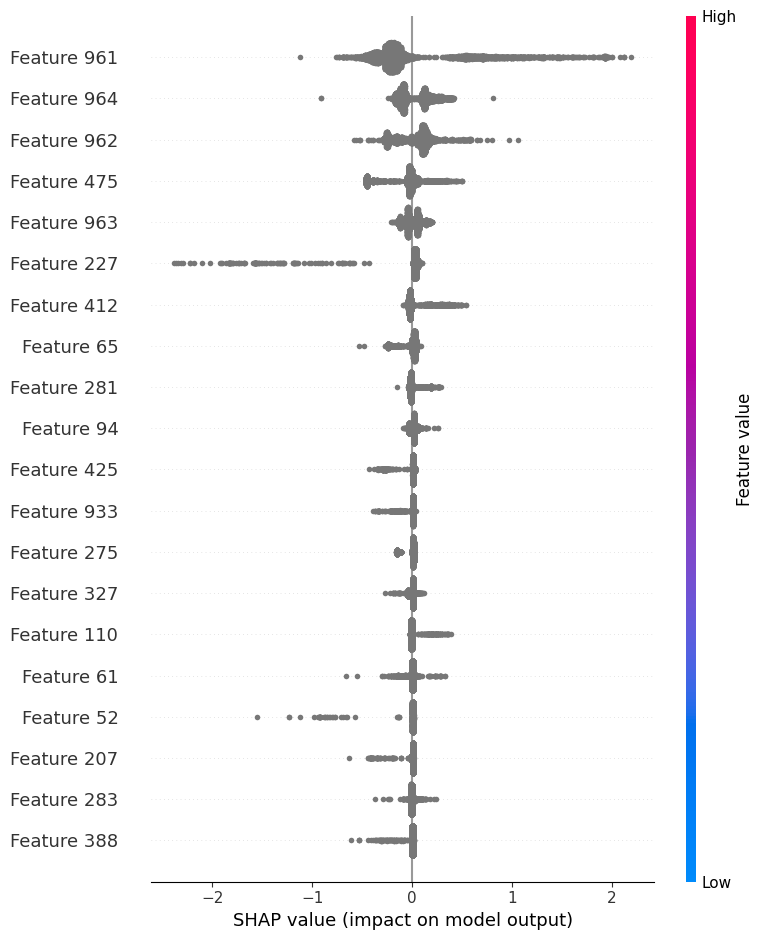

In [69]:
# Fit XGBoost for SHAP
xgb_pipe.fit(X_train, y_train_dur)

# Transform data
X_transformed = xgb_pipe.named_steps['prep'].transform(X_test)

explainer = shap.Explainer(xgb_pipe.named_steps['model'])
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed)

## Feature Importance in the XGBoost Model

This plot shows how much each variable contributes to the model’s overall predictions. The most influential features are *globalgiving*, *set*, and *direct*, meaning the model relies heavily on these to make decisions. Donor-related variables such as *irishaid*, *usaid*, and the *Foreign, Commonwealth Development Office (FCDO)* also play a significant role, indicating that the source of funding strongly affects outcomes. Variables like *start_year* and *country_percent* have moderate influence, suggesting that time and geographic distribution matter but are not the primary drivers. Overall, the model is mainly shaped by funding sources and how aid is structured.


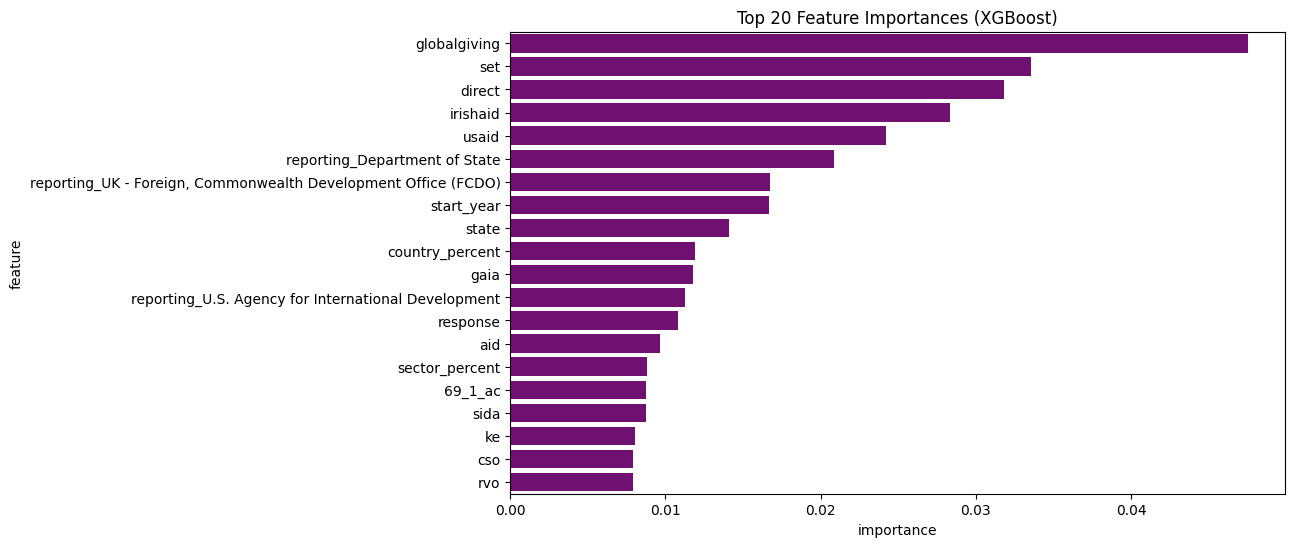

In [ ]:
# Get fitted preprocessor
prep = xgb_pipe.named_steps['prep']

# Extract feature names
# TF-IDF feature names
text_features = prep.named_transformers_['text'].get_feature_names_out()

# OneHotEncoder feature names
cat_features = prep.named_transformers_['cat'].get_feature_names_out(['reporting','sector_group'])

# Numerical features
num_features = ['start_year','start_month','sector_percent','country_percent']

# Combine all
all_features = list(text_features) + list(cat_features) + num_features

# Feature importances
importances = xgb_pipe.named_steps['model'].feature_importances_

# Create dataframe
feat_imp_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot Top 20
plt.figure(figsize=(10,6))
sns.barplot(
    data=feat_imp_df.head(20),
    x='importance',
    y='feature',
    color='purple'
)
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

## SHAP Summary Plot 

This plot explains how each feature influences predictions at a more detailed level by showing both the direction and strength of impact. Features like *start_year* have the widest spread, meaning they can strongly increase or decrease predictions depending on their values. *Country_percent* and *start_month* also show noticeable effects, though less extreme. Interestingly, *globalgiving* tends to push predictions downward in many cases, while donor variables such as *usaid*, *sida*, and *irishaid* have mixed effects depending on the context. Most lower-ranked features cluster around zero, indicating minimal influence. In summary, while funding sources are important, the timing and proportion of aid often determine how predictions shift in specific cases.

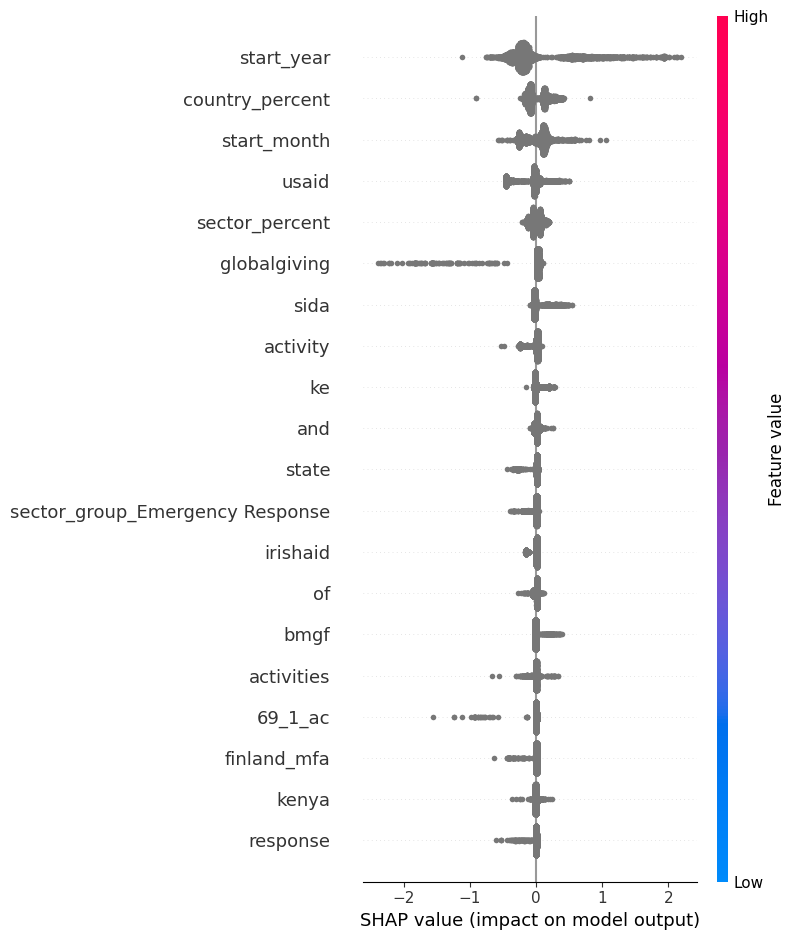

In [73]:
shap.summary_plot(shap_values, X_transformed, feature_names=all_features)

In [75]:
joblib.dump(stack_pipeline, "duration_model.pkl")
joblib.dump(eff_pipeline, "efficiency_model.pkl")

['efficiency_model.pkl']